# Part 1 - Data Visualization and k-NN
In the first three parts, you will work with the GalaxyMNIST dataset. This dataset comprises images of galaxies coupled with class labels and we aim to build the best possible classifier.
In this first part you should get to know the data, implement a simple k-NN classifier and write your own evaluation. 

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch, gzip, requests
from galaxy_mnist import GalaxyMNIST

download_data = [
    {"url":"https://www.dropbox.com/scl/fi/l4ap5eq7z49l27dnfw076/train_dataset.hdf5.gz?rlkey=gjfrrrouoah0hbydbkpfx66as&st=tw6znd55&dl=1", "file":"train_dataset.hdf5"},
    {"url":"https://www.dropbox.com/scl/fi/ty43vhrrpa8cf8azn3awn/test_dataset.hdf5.gz?rlkey=jmlkzjiguhe271nbuzpa0njna&st=5oco8ika&dl=1",  "file":"test_dataset.hdf5"}
]

root = Path("raw_galaxy_mnist")
raw = root/"GalaxyMNIST"/"raw"
raw.mkdir(parents=True, exist_ok=True)
for d in download_data:
    p = raw/d["file"]
    if not p.exists():
        r = requests.get(d["url"], timeout=60)
        p.write_bytes(gzip.decompress(r.content))

dataset = GalaxyMNIST(root=root, train=True)
val_dataset = GalaxyMNIST(root=root, train=False)

In [2]:
# Extract data and targets
raw_images, labels = dataset.data, dataset.targets
raw_test_images, test_labels = val_dataset.data, val_dataset.targets
label_names = dataset.classes
label_count = len(dataset.classes)

# You can add here your analysis or visualization code
print(f"{raw_images.shape = }")
print(f"{raw_images.dtype = }")
print(f"{labels.shape = }")
print(f"{labels.dtype = }")
print(f"{test_labels.shape = }")
print(f"{test_labels.dtype = }")
print(f"{label_names = }")
print(f"{label_count = }")

raw_images.shape = torch.Size([8000, 3, 64, 64])
raw_images.dtype = torch.uint8
labels.shape = torch.Size([8000])
labels.dtype = torch.int64
test_labels.shape = torch.Size([2000])
test_labels.dtype = torch.int64
label_names = ['smooth_round', 'smooth_cigar', 'edge_on_disk', 'unbarred_spiral']
label_count = 4


## 1.1 Simple Data Visualization
- Write the code to plot N images per class.
- Describe in one sentence the apparent differences between the classes.
- Plot a histogram of pixel values of a single image (pixel value on x-axis, count on y-axis) and describe it.

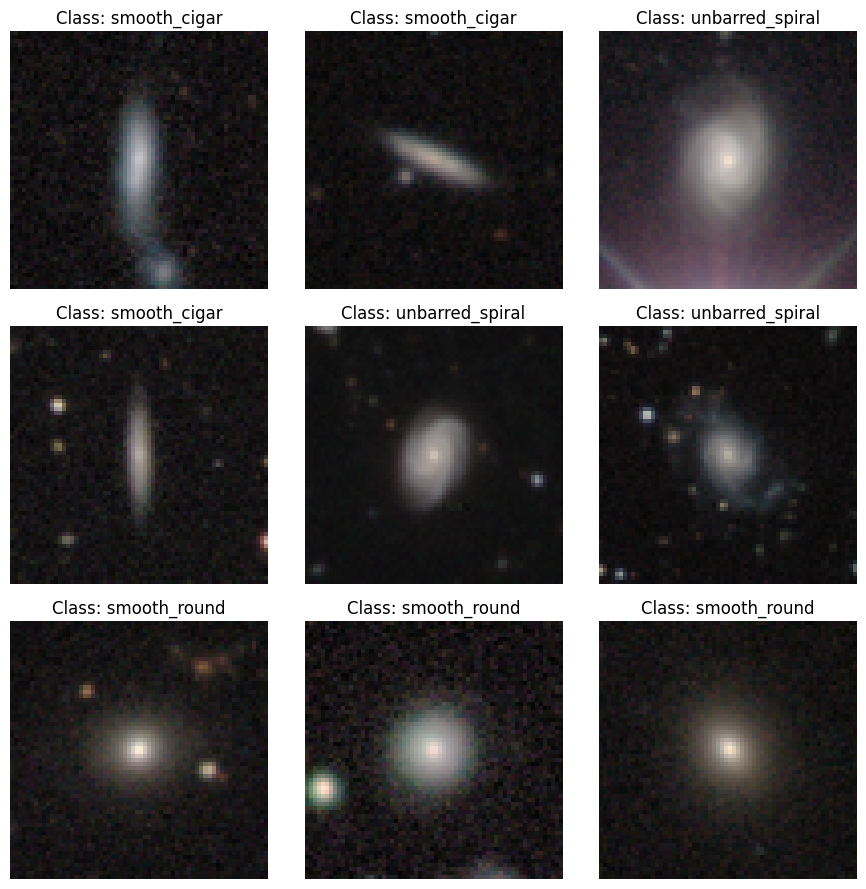

In [3]:
def show_galaxy(image, label, label_names, ax) -> None:
    # permute image shape: (C, H, W) -> (H, W, C) for matplotlib
    img = image.permute(1, 2, 0)

    # normalize to [0, 1]
    img = img / 255

    ax.imshow(img)
    ax.set_title(f"Class: {label_names[label]}")
    ax.axis("off")

    return


fig, axes = plt.subplots(3, 3, figsize=(9, 9))
axes = axes.flatten()

for i in range(9):
    show_galaxy(raw_images[i], labels[i], label_names, axes[i])

plt.tight_layout()
plt.show()

=== === === ===
smooth_round


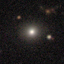

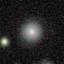

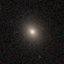

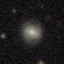

=== === === ===
smooth_cigar


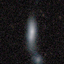

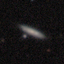

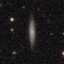

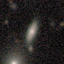

=== === === ===
edge_on_disk


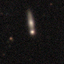

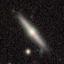

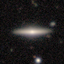

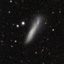

=== === === ===
unbarred_spiral


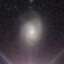

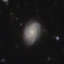

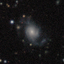

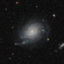

In [4]:
def get_view(data, class_idx):
    return [data[i] for i in range(8000) if labels[i] == class_idx]

def display_images_for_idx(N: int, idx) -> None:
    print('=== === === ===')
    print(label_names[idx])
    display(*[get_view(dataset, idx)[i][0] for i in range(N)])
    return

N = 4

for i in range(len(np.unique(labels))):
    display_images_for_idx(N, i)

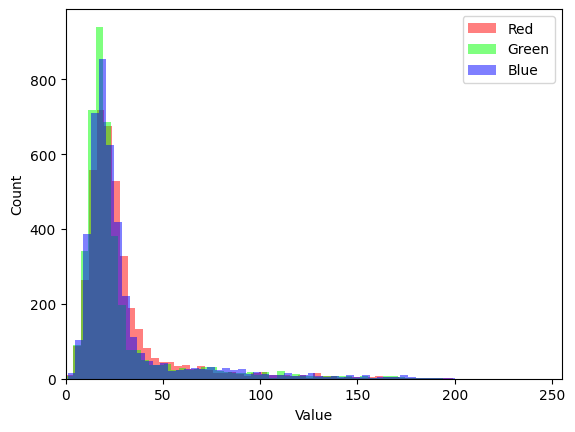

In [5]:
img_num = 0
rgb_values = raw_images[img_num].float()
color_names = ['Red','Green','Blue']
opacity = 0.5
color_rgb_vals = [(1, 0, 0, opacity), (0, 1, 0, opacity), (0, 0, 1, opacity)]

for color, color_name, color_val in zip(rgb_values, color_names, color_rgb_vals):
    color = color.flatten()
    plt.hist(color.numpy(), bins=50, color=color_val, label=color_name)
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.xlim((0, 255))
plt.show();

## 1.2 Standardization of Data

Many machine learning models require or assume the input data to be standardized, meaning to have mean 0 and variance 1. However, there are multiple ways to achieve this for our dataset.
- What are the possible ways to standardize the data? (There is more than one way, think about the dimensions of the data.)
- Which one would you pick? Explain in one sentence why you picked it.
- Perform the standardization and check it. (You won't need a loop to achieve this, but rather use `torch.mean` and `torch.std` with the correct dimensions specified.)

## 1.3 k-Nearest Neighbors
A typical way to classify data is to use the [k-Nearest Neighbors algorithm](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm). In this task we will start with a simple implementation and evaluation and improve upon that.
### 1.3.1 Naive k-NN
- Implement a k-NN classifier using one loop over the test set and another loop over the training set. Do not use a third loop to compute the image distances, but rather use pytorch functions. You can use `tqdm` to show a progress bar for the outer loop to estimate the time it takes to classify the test set. If it would take too long, you can use a subset of the test set for this part.
- Bonus: Are there cases in which the classification criterion of k-nearest neighbors is ambiguous? Note what your implementation does in such cases.

### 1.3.2 Evaluation
Now that you have predictions, a meaningful way to evaluate the classifier is required.

- Read up on classification metrics. Describe the F1 score in one sentence. Why is it important to consider precision and recall together?
- Implement total accuracy (no loop needed). For reference, the accuracy achieved by your implementation with k=3 should be around 60%.
- Compare the results with sci-kit learns `classification_report`.
- Compute the confusion matrix. You may use [sklearn implementation](https://scikit-learn.org/dev/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions). What do you observe?
- Do we have a class imbalance in the dataset? If there was a class imbalance, what is the flaw in using total accuracy as a metric? What are the possible ways to address this issue?

### 1.3.3 Faster k-NN
The double loop implementation computes all distances in sequence, which is slow. A faster way is to compute all distances at once using matrix operations.

- Implement a k-NN classifier that can compute distances between all test and training points at once either by using optimized distance computation functions by torch or scipy or similar libraries.
- Measure the run time of both implementations and write them down. For evaluation, we recommend using the classification report as well as the ConfusionMatrix from scikit-learn.

### 1.3.4 Hyperparameter tuning
An important part of machine learning is hyperparameter tuning. But it can sometimes be tedious to tune hyperparameters by hand through numerous experiments. Fortunately, k-NN only has one hyperparameter.
- Determine based on the accuracy which k leads to the best classifier.
- Plot the accuracy against k.

## 1.4 Exploiting Symmetries and Domain Knowledge

The standard k-Nearest Neighbor approach using Euclidean distance on galaxy images does not leverage any domain-specific knowledge about the data structure.

- **Identify Invariances**: What transformations can be applied to a galaxy image that preserve its class label? In other words, how can you transform an image while keeping it in the same class?

- **Distance Metric Design**: Propose modifications to the distance metric that would make it robust to these transformations. Explain your reasoning. (You don't need to implement this, just describe the approach theoretically.)

- **Data Preprocessing Strategy**: How could you preprocess the dataset to reduce the impact of these transformations on classification? Consider alignment, normalization, or feature extraction approaches.

- **Bonus Implementation Challenge**: Implement one of your proposed approaches and evaluate whether it outperforms the baseline Euclidean distance metric!